# Kolmogorov-Arnold Networks (KANs)

## 1. Instalación

La implementación oficial ("pykan") requiere PyTorch. Se puede instalar via pip:

In [28]:
#%pip install pykan
#%pip install numpy
#%pip install matplotlib
#%pip install torch

## 2. Concepto básico

En una KAN, en lugar de multiplicar por un peso $w$, la señal pasa a través de una función `spline` no lineal $\phi(x)$ que la red aprende.

## 3. Implementación en Python (PyTorch)

In [29]:
import torch
from kan import KAN
import matplotlib.pyplot as plt

In [30]:
# 1. Crear el Dataset
# Simulamos datos basados en una función conocida para probar si la KAN la aprende
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)

# Crear tensores de entrada (2 variables) y salida
num_samples = 1000
dataset = {}
dataset['train_input'] = torch.rand(num_samples, 2) * 2 - 1  # Rango [-1, 1]
dataset['test_input'] = torch.rand(num_samples, 2) * 2 - 1
dataset['train_label'] = f(dataset['train_input'])
dataset['test_label'] = f(dataset['test_input'])


In [31]:
# 2. Definir el Modelo KAN
# width=[2, 5, 1]: 2 entradas -> 5 neuronas ocultas -> 1 salida
# grid=5: Número de intervalos de la cuadrícula (granuaridad de los splines)
# k=3: Orden del spline (3 = cúbico)
model = KAN(width=[2, 5, 1], grid=5, k=3, seed=0)

checkpoint directory created: ./model
saving model version 0.0


In [32]:
# 3. Entrenar el Modelo
# KANs suelen beneficiarse del optimizador LBFGS para alta precisión
results = model.fit(
    dataset,
    opt="LBFGS",
    steps=20,
    lamb=0.01,
    lamb_entropy=10.0)

print("Training Loss:", results['train_loss'][-1])
print("Test Loss:", results['test_loss'][-1])

| train_loss: 1.74e-01 | test_loss: 1.58e-01 | reg: 2.08e+01 | : 100%|█| 20/20 [00:06<00:00,  3.18it

saving model version 0.1
Training Loss: 0.17416467
Test Loss: 0.15761141


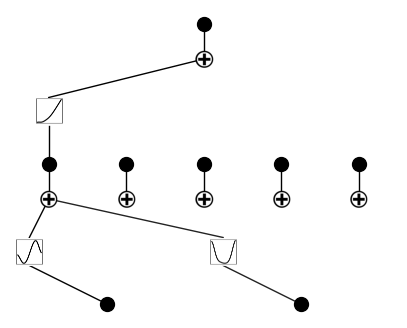

In [33]:
# 4. Visualizar la estructura aprendida
model.plot()

saving model version 0.2


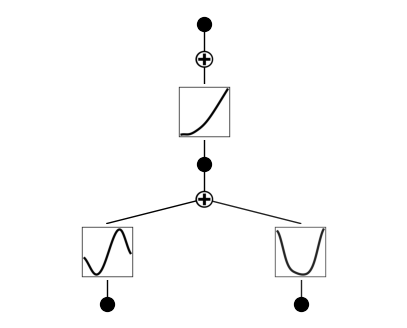

In [34]:
# 1. Prune (Poda): Elimina formalmente las conexiones débiles que ves desconectadas
model = model.prune()

# 2. Plot limpio: Vuelve a graficar para ver solo lo importante
model.plot()

In [35]:
# 3. Obtener la fórmula simbólica
# lib: define qué funciones matemáticas puede usar para intentar "traducir" los dibujos
model.auto_symbolic(lib=['x^2', 'sin', 'exp', 'log', 'sqrt'])

# 4. Imprimir la fórmula final
print(model.symbolic_formula()[0][0])

fixing (0,0,0) with sin, r2=0.9924039840698242, c=2
fixing (0,1,0) with x^2, r2=0.9841592907905579, c=2
fixing (1,0,0) with sin, r2=0.9998253583908081, c=2
saving model version 0.3
6.07293319702148*sin(0.00884064935076895*(0.00959999859333038 - 8.45343971252441*x_2)**2 + 0.527223645951633*sin(3.12544012069702*x_1 - 0.0115199955180287) - 7.51957032586697) + 5.51077032089233
